# **Evaluación: HybridCNN Audio Classifier (`multiclase`)**

Carga el modelo entrenado usando **el mismo pipeline que `inference_test.ipynb`** (autodetección de modo, sin hardcodear `mel_only` / `mel_mfcc`) y evalúa sobre el split `test` del dataset procesado.

Produce:
- Accuracy, F1 macro y reporte por clase
- Matriz de confusión con valores absolutos y normalizada
- Guardado automático de ambas figuras en `FINAL_MODEL_DIR`

## **1. Importaciones**

In [7]:
from __future__ import annotations
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import json as _json
import os as _os

from torch.utils.data import DataLoader
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score,
)
from tqdm import tqdm
from src.utils.config import (
    PROCESSED_METADATA,
    LABEL_MAPPING,
    FINAL_MODEL_DIR,
    CHECKPOINT_DIR,
)
from src.models.hybrid_cnn_v4 import HybridCNNV5
from src.models.audio_dataset import ProcessedAudioDataset, crnn_collate_fn

print("Importaciones completadas.")

Importaciones completadas.


## **2. Configuración**

In [8]:
# ─────────────────────────────────────────────
# RUTAS
# ─────────────────────────────────────────────
MODEL_PATH = FINAL_MODEL_DIR / "best_human_label_v7.pt"
# MODEL_PATH = CHECKPOINT_DIR / "checkpoint_epoch_16.pt" # descomentar esto si usamos checkpoint
# MODEL_PATH = FINAL_MODEL_DIR / "modelV4_32.pt" # descomentar esto si usamos checkpoint

LABEL_MAPPING_PATH = LABEL_MAPPING["human_label2"]
TARGET_TYPE = "human_label"

# ─────────────────────────────────────────────
# DATALOADER
# ─────────────────────────────────────────────
BATCH_SIZE = 32
NUM_WORKERS = 4
DROPOUT = 0.25
PROCESSED_METADATA=PROCESSED_METADATA["2"]
# ─────────────────────────────────────────────
# VISUALIZACIÓN
# ─────────────────────────────────────────────
FIG_SIZE = (16, 13) # tamaño de la figura de la matriz
ANNOT_ABSOLUTE = True # mostrar números en la matriz absoluta
ANNOT_NORM = True # mostrar porcentajes en la normalizada

print(f"- Modelo: {MODEL_PATH}")
print(f"- Label mapping: {LABEL_MAPPING_PATH}")
print(f"- Metadata CSV: {PROCESSED_METADATA}")

- Modelo: /home/andres/Documentos/proyecto4geeks/models/final/best_human_label_v7.pt
- Label mapping: /home/andres/Documentos/proyecto4geeks/data/interim/processed_dataset/label_mapping_human_labelV2.pkl
- Metadata CSV: /home/andres/Documentos/proyecto4geeks/data/interim/processed_dataset/processed_metadataV2.csv


## **3. Device**

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device_name = (
    torch.cuda.get_device_name(0)
    if device.type == "cuda"
    else "CPU"
)
print(f"Dispositivo: {device} | {device_name}")

Dispositivo: cuda | AMD Radeon RX 7600 XT


## **4. Dataset y DataLoader de test**

In [10]:
# Train dataset solo para heredar target_frames
# ProcessedAudioDataset infiere target_frames del primer .npy disponible.
# Usamos el split train como referencia para garantizar consistencia.
train_ds = ProcessedAudioDataset(
    metadata_csv=PROCESSED_METADATA,
    label_mapping_path=LABEL_MAPPING_PATH,
    split="train",
    target_column=TARGET_TYPE,
    use_mfcc=True,
    use_waveform=True, # necesario para el modo mel_waveform
    use_scalars=False,
)

# Test dataset
test_ds = ProcessedAudioDataset(
    metadata_csv=PROCESSED_METADATA,
    label_mapping_path=LABEL_MAPPING_PATH,
    split="test",
    target_column=TARGET_TYPE,
    use_mfcc=True,
    use_waveform=True, # necesario para el modo mel_waveform
    use_scalars=False,
    target_frames=train_ds.target_frames, # CLAVE: los mismos frames que train
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    collate_fn=crnn_collate_fn,
)

# Nombres de clases ordenados por índice
# label_mapping es {label: idx}, necesitamos {idx: label}
class_names = [k for k, v in sorted(test_ds.label_mapping.items(), key=lambda x: x[1])]
NUM_CLASSES = len(class_names)

print(f"- Test set: {len(test_ds):,} muestras")
print(f"- Clases ({NUM_CLASSES}): {class_names}")
print(f"- Target frames: {test_ds.target_frames}")


- Test set: 1,760 muestras
- Clases (10): ['car_crash', 'construction_noise', 'crying', 'dog', 'fight', 'fire', 'glass_breaking', 'gun_explosion', 'siren_alarm', 'traffic']
- Target frames: 301


## **5. Cargar modelo (autodetección de modo)**

In [11]:
def detect_mode_from_state_dict(state_dict: dict) -> str:
    keys = set(state_dict.keys())
    has_mel = any(k.startswith("cnn_mel.") for k in keys)
    has_mfcc = any(k.startswith("cnn_mfcc.") for k in keys)
    has_waveform = any(k.startswith("cnn_wave.") for k in keys)

    if has_mel and has_waveform:
        return "mel_waveform"
    elif has_mel and has_mfcc:
        return "mel_mfcc"
    elif has_mel:
        return "mel_only"
    elif has_mfcc:
        return "mfcc_only"
    else:
        raise ValueError("No se encontraron keys cnn_mel.*, cnn_mfcc.* ni waveform_cnn.* en el state_dict.")

def load_model(model_path: Path, num_classes: int, dropout: float) -> tuple[HybridCNNV5, str]:
    checkpoint = torch.load(model_path, map_location=device, weights_only=False)

    if isinstance(checkpoint, dict) and "model_state" in checkpoint:
        state_dict = checkpoint["model_state"]
        epoch_info = checkpoint.get("epoch", "?")
        acc_info = checkpoint.get("best_acc", "?")
        print(f"Checkpoint - epoch: {epoch_info} | best_acc: {acc_info}")
    else:
        state_dict = checkpoint

    detected_mode = detect_mode_from_state_dict(state_dict)
    print(f"Modo detectado automáticamente: {detected_mode}")

    model = HybridCNNV5(num_classes=num_classes, dropout=dropout, mode=detected_mode,task="multiclass").to(device)
    model.load_state_dict(state_dict)
    model.eval()
    return model, detected_mode

model, MODE = load_model(MODEL_PATH, NUM_CLASSES, DROPOUT)

total_params = sum(p.numel() for p in model.parameters())
print(f"Modelo cargado | {total_params:,} parámetros | modo: {MODE}")

Modo detectado automáticamente: mel_waveform
Modelo cargado | 1,809,418 parámetros | modo: mel_waveform


## **6. Inferencia sobre el split test**

In [12]:
def prepare_inputs(batch: dict, device, mode: str):
    """Prepara los tensores de entrada según el modo del modelo."""
    mel = batch.get("mel", None)
    mfcc = batch.get("mfcc", None)
    waveform = batch.get("waveform", None)

    if mel is not None: mel = mel.to(device)
    if mfcc is not None: mfcc = mfcc.to(device)
    if waveform is not None: waveform = waveform.to(device)

    if mode == "mel_only":
        return {"mel": mel}
    elif mode == "mfcc_only":
        return {"mel": mel, "mfcc": mfcc} # mel ignorado internamente
    elif mode == "mel_waveform":
        return {"mel": mel, "waveform": waveform}
    else: # mel_mfcc
        return {"mel": mel, "mfcc": mfcc}

@torch.no_grad()
def run_inference(model, loader, device, mode) -> tuple[list, list]:
    model.eval()
    y_true, y_pred = [], []

    for batch, labels, _ in tqdm(loader, desc="Evaluando"):
        labels = labels.to(device)
        kwargs = prepare_inputs(batch, device, mode)
        logits = model(**kwargs)
        preds = logits.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    return y_true, y_pred

y_true, y_pred = run_inference(model, test_loader, device, MODE)

acc = accuracy_score(y_true, y_pred)
f1_mac = f1_score(y_true, y_pred, average="macro", zero_division=0)
f1_wt = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"\n- Accuracy: {acc:.4f} | ({acc:.2%})")
print(f"- F1 macro: {f1_mac:.4f}")
print(f"- F1 weighted: {f1_wt:.4f}")


Evaluando: 100%|██████████| 55/55 [00:09<00:00,  5.96it/s]


- Accuracy: 0.8153 | (81.53%)
- F1 macro: 0.8155
- F1 weighted: 0.8155


In [13]:
## **6b. Exportar métricas para el dashboard**
_metrics = {
    "model_accuracy": float(acc),
    "f1_macro": float(f1_mac),
    "f1_weighted": float(f1_wt),
}

_os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
_metrics_path = FINAL_MODEL_DIR / "metrics.json"

with open(_metrics_path, "w", encoding="utf-8") as _f:
    _json.dump(_metrics, _f, ensure_ascii=False, indent=2)

print(f"Métricas guardadas en: {_metrics_path}")
print(_metrics)

Métricas guardadas en: /home/andres/Documentos/proyecto4geeks/models/final/metrics.json
{'model_accuracy': 0.8153409090909091, 'f1_macro': 0.8155325419906084, 'f1_weighted': 0.8155325419906087}


## **7. Reporte por clase**

In [14]:
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    zero_division=0,
    digits=3,
)
print(report)

                    precision    recall  f1-score   support

         car_crash      0.933     0.869     0.900       176
construction_noise      0.850     0.835     0.842       176
            crying      0.794     0.875     0.832       176
               dog      0.904     0.909     0.907       176
             fight      0.950     0.858     0.901       176
              fire      0.817     0.534     0.646       176
    glass_breaking      0.913     0.835     0.872       176
     gun_explosion      0.842     0.972     0.902       176
       siren_alarm      0.706     0.778     0.741       176
           traffic      0.550     0.688     0.611       176

          accuracy                          0.815      1760
         macro avg      0.826     0.815     0.816      1760
      weighted avg      0.826     0.815     0.816      1760



## **8. Matriz de confusión**

Guardada en: /home/andres/Documentos/proyecto4geeks/models/final/confusion_matrix_absolute.png


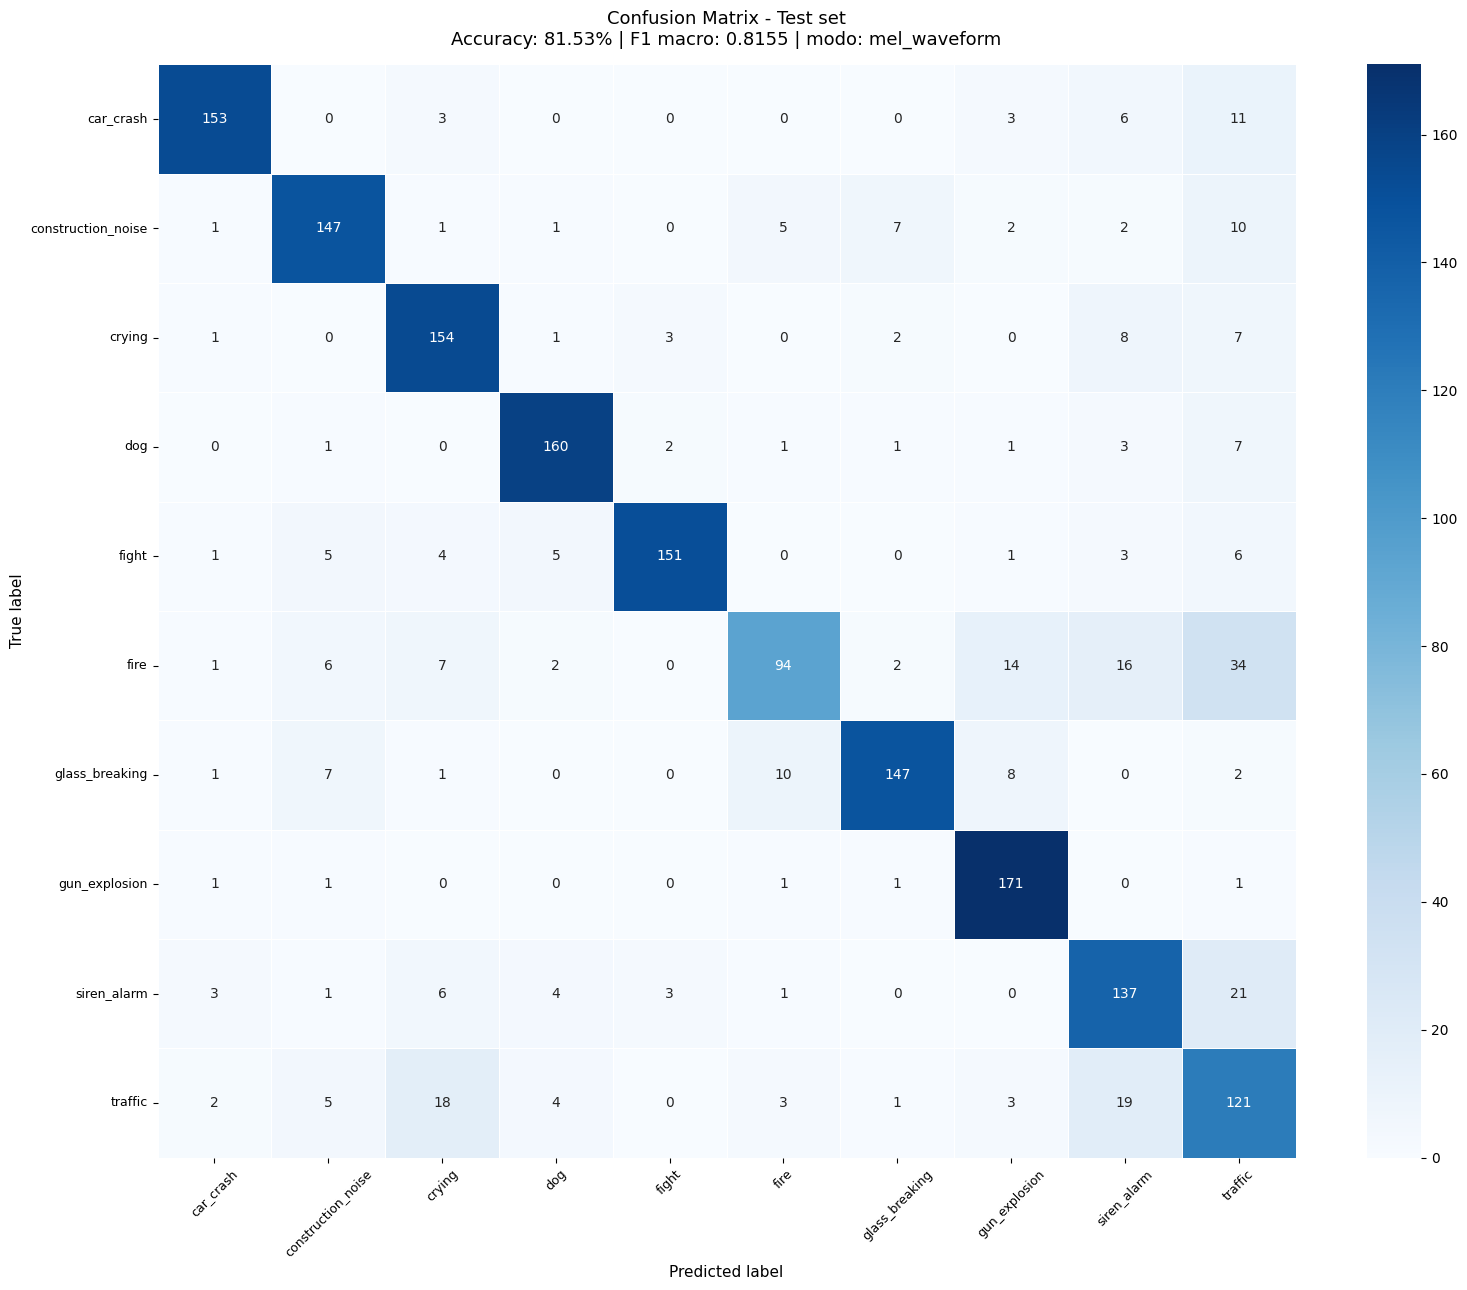

In [15]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=FIG_SIZE)

sns.heatmap(
    cm,
    annot=ANNOT_ABSOLUTE,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title(
    f"Confusion Matrix - Test set\nAccuracy: {acc:.2%} | F1 macro: {f1_mac:.4f} | modo: {MODE}",
    fontsize=13, pad=14,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()

save_path = FINAL_MODEL_DIR / "confusion_matrix_absolute.png"
_os.makedirs(FINAL_MODEL_DIR, exist_ok=True)
fig.savefig(save_path, dpi=180, bbox_inches="tight")
print(f"Guardada en: {save_path}")

plt.show()

## **9. Matriz de confusión normalizada por fila (recall por clase)**

Guardada en: /home/andres/Documentos/proyecto4geeks/models/final/confusion_matrix_normalized.png


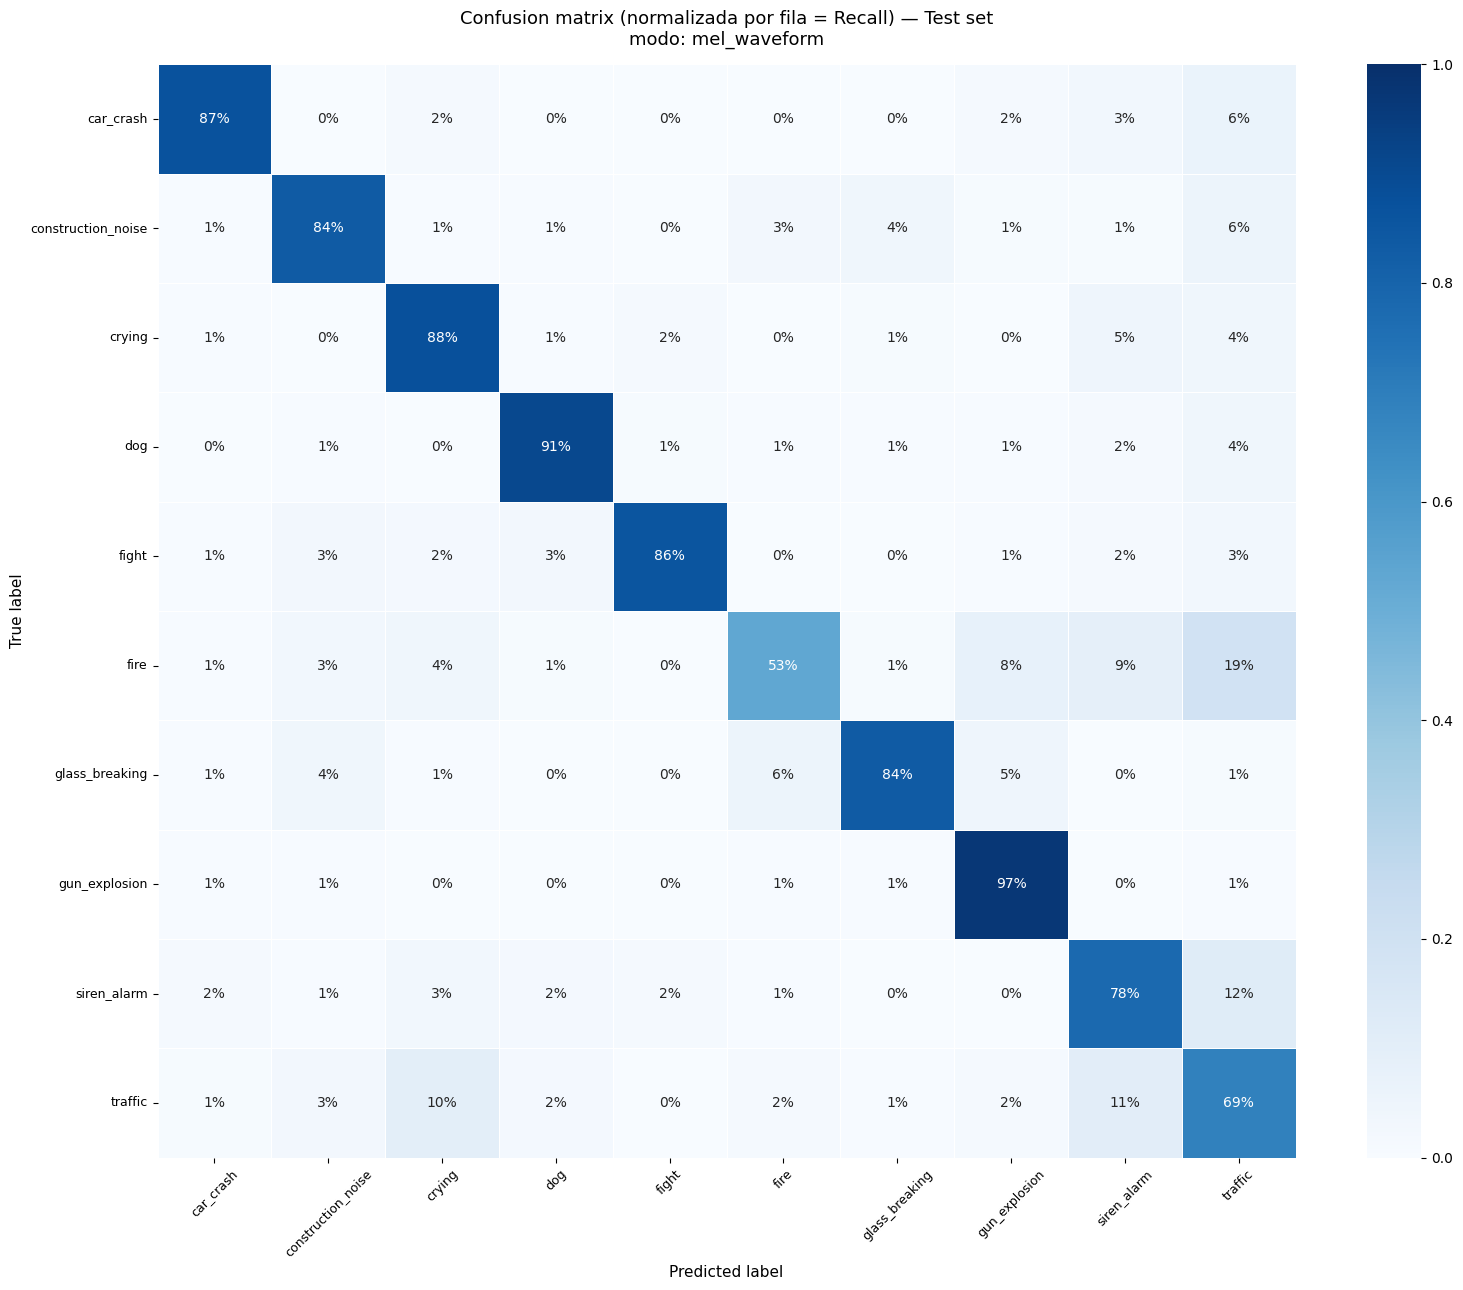

In [16]:
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=FIG_SIZE)

annot_data = (
    np.array([[f"{v:.0%}" for v in row] for row in cm_norm])
    if ANNOT_NORM else False
)

sns.heatmap(
    cm_norm,
    annot=annot_data if ANNOT_NORM else False,
    fmt="",
    cmap="Blues",
    vmin=0, vmax=1,
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="white",
    ax=ax,
)

ax.set_title(
    f"Confusion matrix (normalizada por fila = Recall) — Test set\nmodo: {MODE}",
    fontsize=13, pad=14,
)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.tight_layout()

save_path_norm = FINAL_MODEL_DIR / "confusion_matrix_normalized.png"
fig.savefig(save_path_norm, dpi=180, bbox_inches="tight")
print(f"Guardada en: {save_path_norm}")

plt.show()

## **10. Clases con más errores**

Clases ordenadas por recall (de peor a mejor):


,Clase,Recall,Muestras test
0,fire,53.41%,176
1,traffic,68.75%,176
2,siren_alarm,77.84%,176
3,construction_noise,83.52%,176
4,glass_breaking,83.52%,176
5,fight,85.80%,176
6,car_crash,86.93%,176
7,crying,87.50%,176
8,dog,90.91%,176
9,gun_explosion,97.16%,176



Guardado en: /home/andres/Documentos/proyecto4geeks/models/final/recall_per_class.png


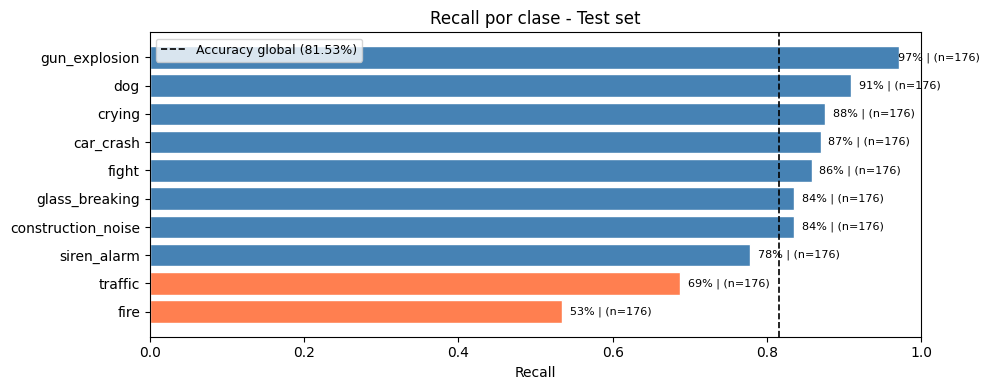

In [17]:
# Recall por clase (diagonal / total real de esa clase)
per_class_recall = cm.diagonal() / cm.sum(axis=1).clip(min=1)

# Cuántas muestras reales tiene cada clase
support = cm.sum(axis=1)

df_perf = (
    pd.DataFrame({
        "class": class_names,
        "recall": per_class_recall,
        "support": support,
    })
    .sort_values("recall")
    .reset_index(drop=True)
)

df_perf["recall_fmt"] = df_perf["recall"].map("{:.2%}".format)

print("Clases ordenadas por recall (de peor a mejor):")
display(df_perf[["class", "recall_fmt", "support"]].rename(
    columns={"class": "Clase", "recall_fmt": "Recall", "support": "Muestras test"}
))

# Barplot
fig, ax = plt.subplots(figsize=(10, max(4, NUM_CLASSES * 0.38)))

colors = ["crimson" if r < 0.5 else "coral" if r < 0.7 else "steelblue"
          for r in df_perf["recall"]]

ax.barh(df_perf["class"], df_perf["recall"], color=colors, edgecolor="white")
ax.axvline(x=acc, color="black", linestyle="--", linewidth=1.2, label=f"Accuracy global ({acc:.2%})")
ax.set_xlim(0, 1)
ax.set_xlabel("Recall")
ax.set_title("Recall por clase - Test set")
ax.legend(fontsize=9)

for i, (r, sup) in enumerate(zip(df_perf["recall"], df_perf["support"])):
    ax.text(min(r + 0.01, 0.97), i, f"{r:.0%} | (n={sup})", va="center", fontsize=8)

plt.tight_layout()

save_path_bar = FINAL_MODEL_DIR / "recall_per_class.png"
fig.savefig(save_path_bar, dpi=150, bbox_inches="tight")
print(f"\nGuardado en: {save_path_bar}")

plt.show()

## **11. Confusiones más frecuentes (top errores)**

In [18]:
# Extraer pares (real, predicho) con más confusiones (fuera de la diagonal)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)

pairs = [
    {
        "true": class_names[i],
        "predicted": class_names[j],
        "count": cm_off[i, j],
        "recall_true": f"{per_class_recall[i]:.0%}",
    }
    for i in range(NUM_CLASSES)
    for j in range(NUM_CLASSES)
    if cm_off[i, j] > 0
]

df_errors = (
    pd.DataFrame(pairs)
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
    .head(20)
)

print("Top-20 confusiones (real --> predicho):")
display(df_errors)

Top-20 confusiones (real --> predicho):


,true,predicted,count,recall_true
0,fire,traffic,34,53%
1,siren_alarm,traffic,21,78%
2,traffic,siren_alarm,19,69%
3,traffic,crying,18,69%
4,fire,siren_alarm,16,53%
5,fire,gun_explosion,14,53%
6,car_crash,traffic,11,87%
7,construction_noise,traffic,10,84%
8,glass_breaking,fire,10,84%
9,glass_breaking,gun_explosion,8,84%
